# 🍷 Wine Quality — SMOTENC + DagsHub / MLflow

## Fluxo
1. EDA + visualização do desbalanceamento
2. Feature engineering
3. **Geração sintética com SMOTENC** (dataset misto: numérico + categórico)
4. Comparação de modelos com/sem balanceamento
5. Tuning via `RandomizedSearchCV`
6. **Tracking completo no DagsHub / MLflow**
7. **Registro e promoção para Production no Model Registry**

## 0. Variáveis de Ambiente

In [7]:
from dotenv import load_dotenv
load_dotenv('../.env', override=True)

import os
DAGSHUB_USERNAME  = os.environ['DAGSHUB_USERNAME']
DAGSHUB_REPO_NAME = os.environ['DAGSHUB_REPO_NAME']
DAGSHUB_TOKEN     = os.environ['DAGSHUB_TOKEN']
MLFLOW_EXPERIMENT = os.getenv('MLFLOW_EXPERIMENT', 'wine-quality')
REGISTERED_MODEL  = os.getenv('MLFLOW_MODEL_NAME', 'wine-quality')

print(f'Usuario  : {DAGSHUB_USERNAME}')
print(f'Repo     : {DAGSHUB_REPO_NAME}')
print(f'Experim. : {MLFLOW_EXPERIMENT}')

Usuario  : frpbotero
Repo     : wine-quality
Experim. : wine-quality


In [8]:
import warnings
warnings.filterwarnings('ignore')

import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.metrics         import (
    classification_report, accuracy_score, f1_score,
    ConfusionMatrixDisplay, precision_recall_fscore_support
)
from scipy.stats             import randint

from imblearn.over_sampling  import SMOTENC, RandomOverSampler

import mlflow
import mlflow.sklearn
from mlflow                  import MlflowClient
from mlflow.models.signature import infer_signature

import dagshub

print('Imports OK')

Imports OK


## 1. Conectar DagsHub → MLflow

`dagshub.init()` configura automaticamente o `MLFLOW_TRACKING_URI`
para o servidor hospedado no DagsHub do seu repositório.

In [9]:
dagshub.init(
    repo_owner=DAGSHUB_USERNAME,
    repo_name=DAGSHUB_REPO_NAME,
    mlflow=True,
)

os.environ['MLFLOW_TRACKING_USERNAME'] = DAGSHUB_USERNAME
os.environ['MLFLOW_TRACKING_PASSWORD'] = DAGSHUB_TOKEN

mlflow.set_experiment(MLFLOW_EXPERIMENT)
print('Tracking URI:', mlflow.get_tracking_uri())

Initialized MLflow to track repo "frpbotero/wine-quality"

Repository frpbotero/wine-quality initialized!

Tracking URI: https://dagshub.com/frpbotero/wine-quality.mlflow


## 2. EDA — Distribuicao de Classes

Shape: (6497, 13)


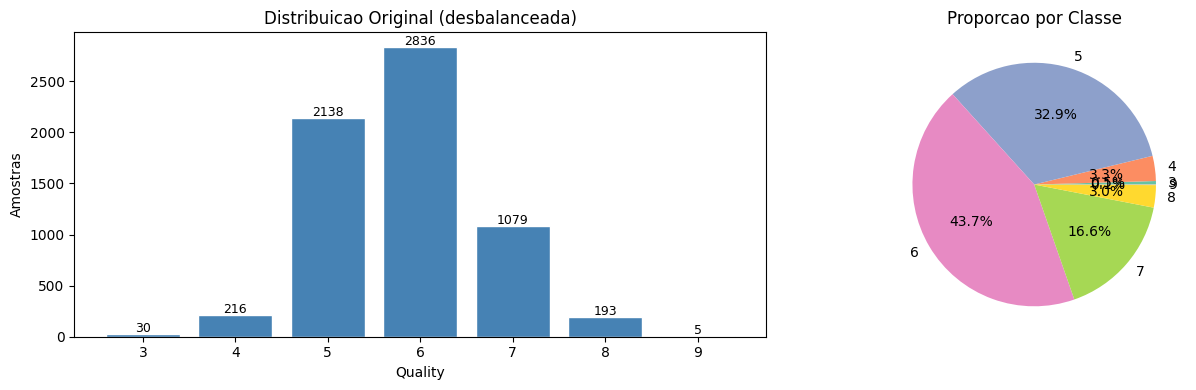

Razao max/min: 567.2 x


In [10]:
df = pd.read_csv('../data/wine_quality_merged.csv')
print(f'Shape: {df.shape}')
vc = df['quality'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bars = axes[0].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
for b, v in zip(bars, vc.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height()+20, str(v), ha='center', fontsize=9)
axes[0].set_title('Distribuicao Original (desbalanceada)')
axes[0].set_xlabel('Quality'); axes[0].set_ylabel('Amostras')
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=sns.color_palette('Set2', len(vc)))
axes[1].set_title('Proporcao por Classe')
plt.tight_layout()
plt.savefig('../reports/class_distribution_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('Razao max/min:', round(vc.max()/vc.min(), 1), 'x')

## 3. Feature Engineering

In [11]:
def add_features(df):
    df = df.copy()
    df['alcohol_sulphates'] = df['alcohol'] * df['sulphates']
    df['acid_ratio']        = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
    df['so2_ratio']         = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-6)
    for col in ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide']:
        df[f'log_{col.replace(" ","_")}'] = np.log1p(df[col])
    return df

df_feat = add_features(df)
X = df_feat.drop(columns=['quality'])
y = df_feat['quality']

CAT_COL   = 'type'
CAT_INDEX = list(X.columns).index(CAT_COL)   # posicao para o SMOTENC
print(f'Coluna "{CAT_COL}" no indice {CAT_INDEX} | Total features: {X.shape[1]}')

Coluna "type" no indice 11 | Total features: 19


## 4. Split Treino/Teste (estratificado — SMOTE so no treino)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')
print(y_train.value_counts().sort_index().to_string())

Treino: (5197, 19) | Teste: (1300, 19)
quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4


## 5. Geracao Sintetica — SMOTENC

**Por que SMOTENC e nao SMOTE puro?**

O dataset tem a coluna `type` (categorica: `red` / `white`).  
SMOTE puro interpolaria essa coluna numericamente → valores invalidos (ex: `0.47`).  
O **SMOTENC** determina o valor categorico dos vizinhos mais proximos por votacao,  
preservando sempre `red` ou `white` nos exemplos sinteticos.

**Estrategia em 2 passos:**

| Passo | Tecnica | Motivo |
|---|---|---|
| 1 | `RandomOverSampler` | Classe 9 tem ~4 amostras no treino. SMOTENC precisa de k+1 vizinhos. Duplicamos ate 20 antes. |
| 2 | `SMOTENC` | Interpola features numericas + vota categoricas pelos k vizinhos mais proximos. |

In [13]:
# Passo 1 — sobe classes com < 10 amostras para 20 (threshold minimo para SMOTENC k=5)
minority_counts = y_train.value_counts()
ros_strategy    = {cls: 20 for cls, cnt in minority_counts.items() if cnt < 10}
print('RandomOverSampler strategy:', ros_strategy)

if ros_strategy:
    ros = RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)
    X_ros, y_ros = ros.fit_resample(X_train, y_train)
else:
    X_ros, y_ros = X_train.copy(), y_train.copy()

print('\nApos RandomOverSampler:')
print(pd.Series(y_ros).value_counts().sort_index().to_string())

RandomOverSampler strategy: {9: 20}

Apos RandomOverSampler:
quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9      20


In [14]:
# Passo 2 — SMOTENC: gera sinteticos respeitando a coluna categorica
current_counts = pd.Series(y_ros).value_counts()

smote_strategy = {
    3: 400,   # 30 originais  → 400 sinteticos
    4: 600,   # 173 originais → 600
    8: 500,   # 154 originais → 500
    9: 200,   # 4  originais  → 200 (apos ROS ja tem 20)
}
# Remove classes que ja superaram o alvo
smote_strategy = {k: v for k, v in smote_strategy.items()
                  if current_counts.get(k, 0) < v}
print('SMOTENC strategy:', smote_strategy)

smotenc = SMOTENC(
    categorical_features=[CAT_INDEX],
    sampling_strategy=smote_strategy,
    k_neighbors=5,
    random_state=42,
)
X_res, y_res = smotenc.fit_resample(X_ros, y_ros)

print(f'\nTreino original  : {X_train.shape[0]} amostras')
print(f'Treino balanceado: {X_res.shape[0]} amostras')

SMOTENC strategy: {3: 400, 4: 600, 8: 500, 9: 200}

Treino original  : 5197 amostras
Treino balanceado: 6542 amostras


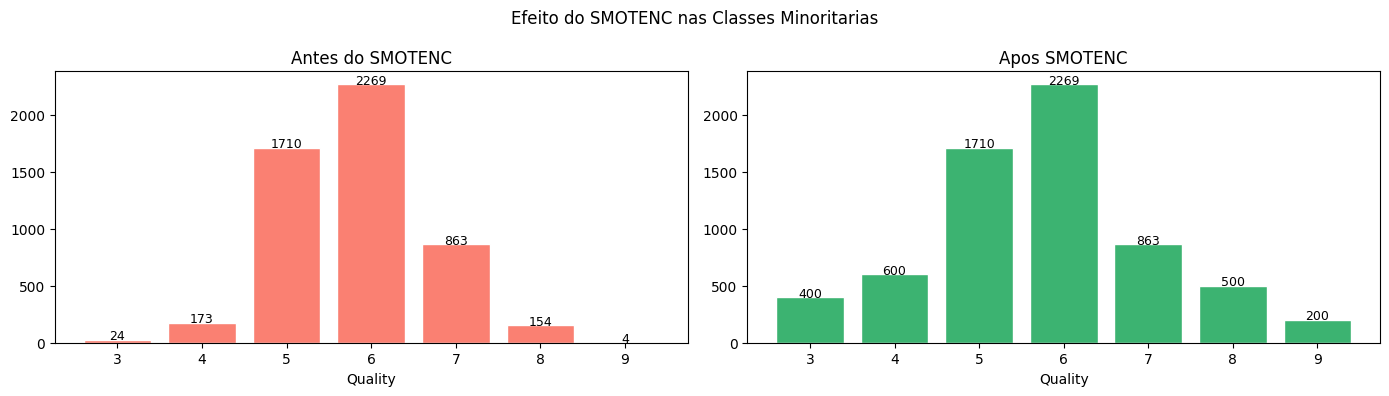

Valores de "type" apos SMOTENC: {'white': 4962, 'red': 1580}
Categorias validas confirmadas.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
vc_before = y_train.value_counts().sort_index()
vc_after  = pd.Series(y_res).value_counts().sort_index()

axes[0].bar(vc_before.index, vc_before.values, color='salmon',        edgecolor='white')
axes[0].set_title('Antes do SMOTENC'); axes[0].set_xlabel('Quality')
axes[1].bar(vc_after.index,  vc_after.values,  color='mediumseagreen', edgecolor='white')
axes[1].set_title('Apos SMOTENC');     axes[1].set_xlabel('Quality')

for ax, vc in [(axes[0], vc_before), (axes[1], vc_after)]:
    for x, v in zip(vc.index, vc.values):
        ax.text(x, v+5, str(v), ha='center', fontsize=9)

plt.suptitle('Efeito do SMOTENC nas Classes Minoritarias')
plt.tight_layout()
plt.savefig('../reports/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Valida que SMOTENC nao gerou categorias invalidas
type_res = X_res.iloc[:, CAT_INDEX].value_counts()
print('Valores de "type" apos SMOTENC:', type_res.to_dict())
assert set(type_res.index) <= {'red', 'white'}, 'SMOTENC gerou valor categorico invalido!'
print('Categorias validas confirmadas.')

In [18]:
# Reconstroi DataFrame com nomes de colunas (necessario para o ColumnTransformer)
X_train_bal = pd.DataFrame(X_res, columns=X.columns)
y_train_bal = pd.Series(y_res, name='quality').astype(int)

# SMOTENC retorna tudo como object — restaura dtypes
for col in X_train_bal.columns:
    if col != CAT_COL:
        X_train_bal[col] = X_train_bal[col].astype(float)

print(f'X_train_bal: {X_train_bal.shape} | y_train_bal: {y_train_bal.shape}')

X_train_bal: (6542, 19) | y_train_bal: (6542,)


## 6. Preprocessor

In [19]:
num_cols = [c for c in X.columns if c != CAT_COL]
cat_cols = [CAT_COL]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                     num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

## 7. Comparacao — com e sem SMOTENC

Mesmos modelos treinados nas duas condicoes para isolar o efeito do balanceamento.

RF_orig       acc=0.6683 +/- 0.0111
RF_bal        acc=0.7265 +/- 0.0202
GB_orig       acc=0.6336 +/- 0.0163
GB_bal        acc=0.6808 +/- 0.0294


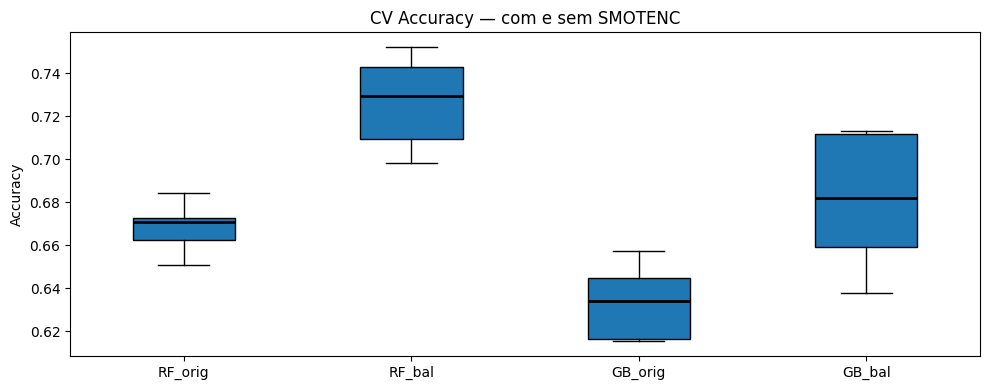

In [20]:
candidates = {
    'RF_orig':  (RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),                           X_train,     y_train),
    'RF_bal':   (RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),                           X_train_bal, y_train_bal),
    'GB_orig':  (GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42), X_train,     y_train),
    'GB_bal':   (GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42), X_train_bal, y_train_bal),
}

cv_results = {}
for name, (clf, Xtr, ytr) in candidates.items():
    pipe   = Pipeline([('pre', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, Xtr, ytr, cv=5, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:12s}  acc={scores.mean():.4f} +/- {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot([cv_results[k] for k in cv_results], labels=list(cv_results.keys()),
           patch_artist=True, medianprops=dict(color='black', linewidth=2))
ax.set_title('CV Accuracy — com e sem SMOTENC')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig('../reports/model_comparison_smote.png', dpi=150)
plt.show()

## 8. Tuning do Melhor Modelo

In [21]:
best_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist = {
    'clf__n_estimators':     randint(200, 600),
    'clf__max_depth':        [None, 10, 20, 30],
    'clf__min_samples_leaf': randint(1, 8),
    'clf__max_features':     ['sqrt', 'log2', 0.5],
    'clf__class_weight':     ['balanced', 'balanced_subsample', None],
}

search = RandomizedSearchCV(
    best_pipe, param_dist,
    n_iter=30, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=42, verbose=1, refit=True
)
search.fit(X_train_bal, y_train_bal)

print('Melhores parametros:', search.best_params_)
print(f'Melhor CV accuracy : {search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores parametros: {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 20, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 227}
Melhor CV accuracy : 0.7299


## 9. Avaliacao Final (conjunto de teste original)

Accuracy      : 0.6862
F1 (weighted) : 0.6805
F1 (macro)    : 0.3950

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.26      0.19      0.22        43
           5       0.75      0.69      0.72       428
           6       0.67      0.79      0.73       567
           7       0.71      0.56      0.63       216
           8       0.55      0.41      0.47        39
           9       0.00      0.00      0.00         1

    accuracy                           0.69      1300
   macro avg       0.42      0.38      0.40      1300
weighted avg       0.68      0.69      0.68      1300



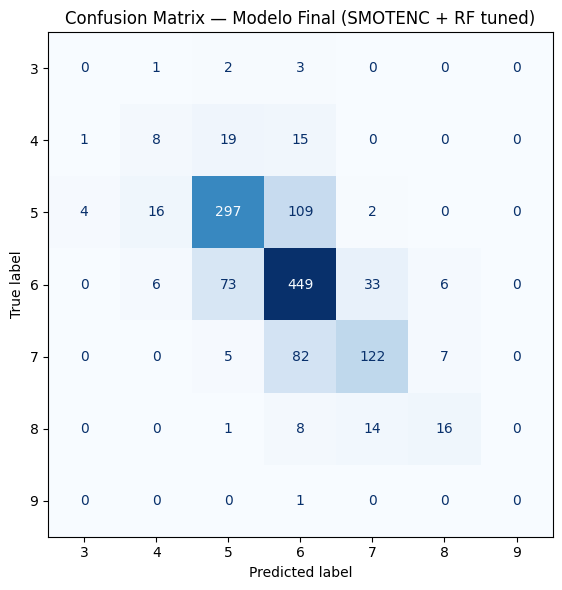

In [22]:
final_model = search.best_estimator_
y_pred      = final_model.predict(X_test)       # X_test NAO passou por SMOTE

test_acc    = accuracy_score(y_test, y_pred)
test_f1_w   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
test_f1_mac = f1_score(y_test, y_pred, average='macro',    zero_division=0)

print(f'Accuracy      : {test_acc:.4f}')
print(f'F1 (weighted) : {test_f1_w:.4f}')
print(f'F1 (macro)    : {test_f1_mac:.4f}')
print()
print(classification_report(y_test, y_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Modelo Final (SMOTENC + RF tuned)')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_final.png', dpi=150)
plt.show()

## 10. Tracking no DagsHub / MLflow

Um unico `run` registra tudo:
- **Tags**: contexto do experimento
- **Params**: hiperparametros + configuracoes do SMOTENC
- **Metrics**: accuracy, F1, metricas por classe
- **Artifacts**: graficos, relatorio JSON
- **Model**: pipeline serializado (preprocessor + classifier)

In [25]:
os.makedirs('../reports', exist_ok=True)

with mlflow.start_run(run_name='RF_SMOTENC_tuned') as run:
    run_id = run.info.run_id
    print(f'Run ID: {run_id}')

    # Tags
    mlflow.set_tags({
        'model_type'    : 'RandomForestClassifier',
        'balancing'     : 'SMOTENC + RandomOverSampler',
        'dataset'       : 'wine_quality_merged',
        'smote_strategy': json.dumps(smote_strategy),
    })

    # Params — modelo
    bp = search.best_params_
    mlflow.log_params({
        'n_estimators'    : bp['clf__n_estimators'],
        'max_depth'       : str(bp['clf__max_depth']),
        'min_samples_leaf': bp['clf__min_samples_leaf'],
        'max_features'    : bp['clf__max_features'],
        'class_weight'    : str(bp['clf__class_weight']),
        'cv_best_score'   : round(search.best_score_, 4),
    })

    # Params — SMOTENC
    mlflow.log_params({
        'train_orig'     : X_train.shape[0],
        'train_balanced' : X_train_bal.shape[0],
        'test_size'      : X_test.shape[0],
        'n_features'     : X.shape[1],
        **{f'smote_cls_{k}': v for k, v in smote_strategy.items()},
    })

    # Metrics — globais
    mlflow.log_metrics({
        'test_accuracy'   : round(test_acc,    4),
        'test_f1_weighted': round(test_f1_w,   4),
        'test_f1_macro'   : round(test_f1_mac, 4),
    })

    # Metrics — por classe
    prec, rec, f1c, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=sorted(y_test.unique()), zero_division=0
    )
    for cls, p, r, f in zip(sorted(y_test.unique()), prec, rec, f1c):
        mlflow.log_metrics({
            f'precision_cls{cls}': round(p, 4),
            f'recall_cls{cls}'   : round(r, 4),
            f'f1_cls{cls}'       : round(f, 4),
        })

    # Artifacts — graficos
    for fpath in [
        '../reports/class_distribution_original.png',
        '../reports/smote_comparison.png',
        '../reports/model_comparison_smote.png',
        '../reports/confusion_matrix_final.png',
    ]:
        if os.path.exists(fpath):
            mlflow.log_artifact(fpath, artifact_path='reports')

    # Artifact — classification report como JSON
    report_path = '../reports/classification_report.json'
    with open(report_path, 'w') as fp:
        json.dump(classification_report(y_test, y_pred, output_dict=True, zero_division=0), fp, indent=2)
    mlflow.log_artifact(report_path, artifact_path='reports')

    # Modelo — com assinatura e exemplo de entrada
    signature  = infer_signature(X_test, y_pred)
    model_info = mlflow.sklearn.log_model(
        sk_model=final_model,
        artifact_path='model',
        signature=signature,
        registered_model_name=REGISTERED_MODEL,
    )

    print(f'Run concluida! Model URI: {model_info.model_uri}')

print(f'Run ID: {run_id}')

Run ID: 5236374f647948cb8307b74748397186


2026/04/28 23:30:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 23:30:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'wine-quality'.
2026/04/28 23:32:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine-quality, version 1
Created version '1' of model 'wine-quality'.


Run concluida! Model URI: models:/m-cbc4d9fb02984497b4c229ca5a602e7c
🏃 View run RF_SMOTENC_tuned at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/0/runs/5236374f647948cb8307b74748397186
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/0
Run ID: 5236374f647948cb8307b74748397186


## 11. Model Registry — Promocao para Production

Busca a versao recem-registrada e a transita para **Production**,
arquivando automaticamente versoes anteriores.

In [26]:
client = MlflowClient()
time.sleep(3)   # aguarda disponibilidade no servidor DagsHub

# Ultima versao registrada (stage None = recem adicionada)
latest = client.get_latest_versions(REGISTERED_MODEL, stages=['None'])
if not latest:
    latest = client.get_latest_versions(REGISTERED_MODEL)
new_version = latest[-1].version
print(f'Nova versao registrada: v{new_version}')

# Promove para Production (arquiva versoes anteriores automaticamente)
client.transition_model_version_stage(
    name=REGISTERED_MODEL,
    version=new_version,
    stage='Production',
    archive_existing_versions=True,
)

# Adiciona descricao da versao
client.update_model_version(
    name=REGISTERED_MODEL,
    version=new_version,
    description=(
        f'RF tuned + SMOTENC. '
        f'Acc={test_acc:.4f}, F1_w={test_f1_w:.4f}, F1_mac={test_f1_mac:.4f}. '
        f'Run: {run_id}'
    )
)

print(f'v{new_version} promovida para Production!')
print(f'URI de carga: models:/{REGISTERED_MODEL}/Production')

Nova versao registrada: v1
v1 promovida para Production!
URI de carga: models:/wine-quality/Production


## 12. Smoke Test — simula o carregamento que o Streamlit fara

In [27]:
model_uri  = f'models:/{REGISTERED_MODEL}/Production'
loaded     = mlflow.sklearn.load_model(model_uri)
smoke_pred = loaded.predict(X_test.iloc[:5])

print(f'Modelo carregado de : {model_uri}')
print(f'Predicoes (amostra) : {smoke_pred.tolist()}')
print(f'Labels reais        : {y_test.iloc[:5].tolist()}')
print('Smoke test OK!')

Modelo carregado de : models:/wine-quality/Production
Predicoes (amostra) : [7, 6, 6, 5, 7]
Labels reais        : [7, 5, 5, 5, 6]
Smoke test OK!
